### 1. Setup and Data Loading

In [225]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import pyarrow as pa

In [226]:
# Initial setup for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 6)

In [227]:
# --- Load the data ---
file_path = "../data/raw/fires-all.csv"

In [228]:
try:
    # Cargar con polars, infiriendo el esquema automáticamente
    df = pl.read_csv(file_path, try_parse_dates=True)
    print(f'Dataset loaded. Dimensions: {df.shape}')
except Exception as e:
    print(f'Error loading file: {e}')

Dataset loaded. Dimensions: (292181, 21)


### 2. Overview and Initial Cleaning
##### 2.1. Structure and Data Types

In [229]:
# Mostrar las primeras filas y el esquema
print("----- First 5 rows -----")
print(df.head())

print("\n----- DataFrame Schema -----")
print(df.schema)

----- First 5 rows -----
shape: (5, 21)
┌────────────┬────────────┬────────────┬──────┬───┬──────────┬────────┬────────┬──────────┐
│ id         ┆ superficie ┆ fecha      ┆ lat  ┆ … ┆ personal ┆ medios ┆ gastos ┆ perdidas │
│ ---        ┆ ---        ┆ ---        ┆ ---  ┆   ┆ ---      ┆ ---    ┆ ---    ┆ ---      │
│ i64        ┆ f64        ┆ date       ┆ str  ┆   ┆ i64      ┆ i64    ┆ i64    ┆ i64      │
╞════════════╪════════════╪════════════╪══════╪═══╪══════════╪════════╪════════╪══════════╡
│ 1968290001 ┆ 14.0       ┆ 1968-01-01 ┆ null ┆ … ┆ 0        ┆ 0      ┆ 0      ┆ 0        │
│ 1968430003 ┆ 3.0        ┆ 1968-01-03 ┆ null ┆ … ┆ 0        ┆ 0      ┆ 0      ┆ 0        │
│ 1968290006 ┆ 2.0        ┆ 1968-01-06 ┆ null ┆ … ┆ 0        ┆ 0      ┆ 0      ┆ 0        │
│ 1968120007 ┆ 8.2        ┆ 1968-01-07 ┆ null ┆ … ┆ 0        ┆ 0      ┆ 0      ┆ 0        │
│ 1968430016 ┆ 600.0      ┆ 1968-01-07 ┆ null ┆ … ┆ 35       ┆ 1      ┆ 0      ┆ 0        │
└────────────┴────────────┴────────────┴

In [230]:
# Resumen estadístico de columnas numéricas
print("\n----- Statistical Summary (Numerical) -----")
print(df.describe())


----- Statistical Summary (Numerical) -----
shape: (9, 22)
┌────────────┬──────────┬───────────┬───────────┬───┬───────────┬──────────┬───────────┬───────────┐
│ statistic  ┆ id       ┆ superfici ┆ fecha     ┆ … ┆ personal  ┆ medios   ┆ gastos    ┆ perdidas  │
│ ---        ┆ ---      ┆ e         ┆ ---       ┆   ┆ ---       ┆ ---      ┆ ---       ┆ ---       │
│ str        ┆ f64      ┆ ---       ┆ str       ┆   ┆ f64       ┆ f64      ┆ f64       ┆ f64       │
│            ┆          ┆ f64       ┆           ┆   ┆           ┆          ┆           ┆           │
╞════════════╪══════════╪═══════════╪═══════════╪═══╪═══════════╪══════════╪═══════════╪═══════════╡
│ count      ┆ 292181.0 ┆ 292181.0  ┆ 292181    ┆ … ┆ 292181.0  ┆ 292181.0 ┆ 292181.0  ┆ 292181.0  │
│ null_count ┆ 0.0      ┆ 0.0       ┆ 0         ┆ … ┆ 0.0       ┆ 0.0      ┆ 0.0       ┆ 0.0       │
│ mean       ┆ 1.9952e9 ┆ 26.751764 ┆ 1995-05-2 ┆ … ┆ 22.088757 ┆ 2.065531 ┆ 593.28045 ┆ 8461.0676 │
│            ┆          ┆      

> <br/>
> 💡 Initial Observations:
>
> - Time range: 1968-2023. => Target range: 2013 - 2023.
> - Key Columns: superficie, fecha, lat, lng, gastos, perdidas, etc.
> - Missing Data: According to documentation, fields like gastos and perdidas have many null values. time_ctrl, time_ext, personal, medios also. => Filter by the target columns of the analysis.
> - ID type columns: idcomunidad, idprovincia
>
> <br/>


##### 2.2. Data Cleaning and Null Handling

In [231]:
# Mapping province names to autonomous communities
provincia_to_ccaa = {
    'ALMERIA': 'ANDALUCIA',
    'CADIZ': 'ANDALUCIA',
    'CORDOBA': 'ANDALUCIA',
    'GRANADA': 'ANDALUCIA',
    'HUELVA': 'ANDALUCIA',
    'JAEN': 'ANDALUCIA',
    'MALAGA': 'ANDALUCIA',
    'SEVILLA': 'ANDALUCIA',

    'HUESCA': 'ARAGON',
    'TERUEL': 'ARAGON',
    'ZARAGOZA': 'ARAGON',

    'ASTURIAS': 'ASTURIAS',

    'BALEARES': 'BALEARES',
    'ILLES BALEARS': 'BALEARES',

    'LAS PALMAS': 'CANARIAS',
    'STA. CRUZ DE TENERIFE': 'CANARIAS',
    'SANTA CRUZ DE TENERIFE': 'CANARIAS',

    'CANTABRIA': 'CANTABRIA',
    'SANTANDER': 'CANTABRIA',

    'ALBACETE': 'CASTILLA-LA MANCHA',
    'CIUDAD REAL': 'CASTILLA-LA MANCHA',
    'CUENCA': 'CASTILLA-LA MANCHA',
    'GUADALAJARA': 'CASTILLA-LA MANCHA',
    'TOLEDO': 'CASTILLA-LA MANCHA',

    'AVILA': 'CASTILLA Y LEON',
    'BURGOS': 'CASTILLA Y LEON',
    'LEON': 'CASTILLA Y LEON',
    'PALENCIA': 'CASTILLA Y LEON',
    'SALAMANCA': 'CASTILLA Y LEON',
    'SEGOVIA': 'CASTILLA Y LEON',
    'SORIA': 'CASTILLA Y LEON',
    'VALLADOLID': 'CASTILLA Y LEON',
    'ZAMORA': 'CASTILLA Y LEON',

    'BARCELONA': 'CATALUNA',
    'GIRONA': 'CATALUNA',
    'LLEIDA': 'CATALUNA',
    'TARRAGONA': 'CATALUNA',

    'BADAJOZ': 'EXTREMADURA',
    'CACERES': 'EXTREMADURA',

    'A CORUÑA': 'GALICIA',
    'LUGO': 'GALICIA',
    'OURENSE': 'GALICIA',
    'PONTEVEDRA': 'GALICIA',

    'LA RIOJA': 'LA RIOJA',

    'MADRID': 'MADRID',

    'MURCIA': 'MURCIA',

    'NAVARRA': 'NAVARRA',

    'ALAVA': 'PAIS VASCO',
    'ARABA/ALAVA': 'PAIS VASCO',
    'GUIPUZCOA': 'PAIS VASCO',
    'GIPUZKOA': 'PAIS VASCO',
    'BIZKAIA': 'PAIS VASCO',
    'VIZCAYA': 'PAIS VASCO',

    'ALICANTE': 'VALENCIA',
    'CASTELLON': 'VALENCIA',
    'VALENCIA': 'VALENCIA',

    'CEUTA': 'CEUTA',
    'MELILLA': 'MELILLA'
}

In [232]:
# Diccionario de provincias (códigos INE 01-52)
provincia_map = {
    1: 'Álava', 2: 'Albacete', 3: 'Alicante', 4: 'Almería', 5: 'Ávila',
    6: 'Badajoz', 7: 'Baleares', 8: 'Barcelona', 9: 'Burgos', 10: 'Cáceres',
    11: 'Cádiz', 12: 'Castellón', 13: 'Ciudad Real', 14: 'Córdoba', 15: 'A Coruña',
    16: 'Cuenca', 17: 'Girona', 18: 'Granada', 19: 'Guadalajara', 20: 'Guipúzcoa',
    21: 'Huelva', 22: 'Huesca', 23: 'Jaén', 24: 'León', 25: 'Lleida',
    26: 'La Rioja', 27: 'Lugo', 28: 'Madrid', 29: 'Málaga', 30: 'Murcia',
    31: 'Navarra', 32: 'Ourense', 33: 'Asturias', 34: 'Palencia', 35: 'Las Palmas',
    36: 'Pontevedra', 37: 'Salamanca', 38: 'Santa Cruz de Tenerife', 39: 'Cantabria',
    40: 'Segovia', 41: 'Sevilla', 42: 'Soria', 43: 'Tarragona', 44: 'Teruel',
    45: 'Toledo', 46: 'Valencia', 47: 'Valladolid', 48: 'Vizcaya', 49: 'Zamora',
    50: 'Zaragoza', 51: 'Ceuta', 52: 'Melilla'
}

In [233]:
# Rename province and map to autonomous community

df = df.with_columns(
    pl.col("idprovincia").replace_strict(provincia_map, default="Desconocido").str.to_uppercase().alias("provincia")
).with_columns(
    pl.col("provincia").replace_strict(provincia_to_ccaa, default="UNKNOWN").alias("cc_aa")
)

In [234]:
# Renombrado de columnas objetivo
df = df.rename({
    'superficie': 'superficie_quemada',  # target variable
    'fecha': 'fecha_incendio',
    'lat': 'latitud',
    'lng': 'longitud',
    'causa': 'causa_incendio'
})

In [235]:
# Filtrar por las columnas objetivo del análisis
columnas_objetivo = [
    'id', 'superficie_quemada', 'fecha_incendio', 'latitud', 'longitud',
    'cc_aa', 'provincia', 'causa_incendio'
]

df = df.select(columnas_objetivo)

In [236]:
# Resumen de columnas
print("\n----- Summary -----")
print(df.columns)


----- Summary -----
['id', 'superficie_quemada', 'fecha_incendio', 'latitud', 'longitud', 'cc_aa', 'provincia', 'causa_incendio']


### 3. Univariate Analysis (Distributions)
##### 3.1. Numerical Variables: superficie_quemada, latitud and longitud

In [237]:
# Primero, verificar el rango temporal y filtrar por el período objetivo (2013-2023)
print("\n----- Date range -----")
print(f"Minimum date: {df['fecha_incendio'].min()}")
print(f"Maximum date: {df['fecha_incendio'].max()}")


----- Date range -----
Minimum date: 1968-01-01
Maximum date: 2023-12-08


In [238]:
# Filtrar por el período 2013-2023
df = df.filter(
    (pl.col('fecha_incendio').dt.year() >= 2013) & 
    (pl.col('fecha_incendio').dt.year() <= 2023)
)

print(f"\nData after filtering for period 2013-2023: {df.shape}")


Data after filtering for period 2013-2023: (27289, 8)


In [239]:
# Verificar nulos después del filtrado
null_percent_filtrado = df.select([
    pl.col(col).is_null().mean().round(4) * 100 for col in df.columns
])
print("\n----- Null Percentage after filtering -----")
print(null_percent_filtrado)


----- Null Percentage after filtering -----
shape: (1, 8)
┌─────┬─────────────────┬────────────────┬─────────┬──────────┬───────┬───────────┬────────────────┐
│ id  ┆ superficie_quem ┆ fecha_incendio ┆ latitud ┆ longitud ┆ cc_aa ┆ provincia ┆ causa_incendio │
│ --- ┆ ada             ┆ ---            ┆ ---     ┆ ---      ┆ ---   ┆ ---       ┆ ---            │
│ f64 ┆ ---             ┆ f64            ┆ f64     ┆ f64      ┆ f64   ┆ f64       ┆ f64            │
│     ┆ f64             ┆                ┆         ┆          ┆       ┆           ┆                │
╞═════╪═════════════════╪════════════════╪═════════╪══════════╪═══════╪═══════════╪════════════════╡
│ 0.0 ┆ 0.0             ┆ 0.0            ┆ 0.0     ┆ 0.0      ┆ 0.0   ┆ 0.0       ┆ 0.0            │
└─────┴─────────────────┴────────────────┴─────────┴──────────┴───────┴───────────┴────────────────┘


In [240]:
# Para el análisis, consideramos que 'superficie_quemada' es la variable más importante
df = df.drop_nulls(subset=['superficie_quemada', 'latitud', 'longitud'])

print(f"\nData after dropping nulls in critical columns: {df.shape}")


Data after dropping nulls in critical columns: (27288, 8)


In [241]:
# Crear columnas auxiliares para el análisis temporal
df = df.with_columns([
    pl.col('fecha_incendio').dt.year().alias('año'),
    pl.col('fecha_incendio').dt.month().alias('mes'),
    pl.col('fecha_incendio').dt.quarter().alias('trimestre')
])

print(f"\nAvailable columns after cleaning: {df.columns}")


Available columns after cleaning: ['id', 'superficie_quemada', 'fecha_incendio', 'latitud', 'longitud', 'cc_aa', 'provincia', 'causa_incendio', 'año', 'mes', 'trimestre']


##### 3.2 Univariate Analysis - Numerical Variables

In [242]:
# Usamos describe() sobre el DataFrame con las columnas numéricas
stats_superficie = df.select(['superficie_quemada']).describe()
print("\n----- Burned Area Statistics (ha) -----")
print(stats_superficie)


----- Burned Area Statistics (ha) -----
shape: (9, 2)
┌────────────┬────────────────────┐
│ statistic  ┆ superficie_quemada │
│ ---        ┆ ---                │
│ str        ┆ f64                │
╞════════════╪════════════════════╡
│ count      ┆ 27288.0            │
│ null_count ┆ 0.0                │
│ mean       ┆ 25.408579          │
│ std        ┆ 245.232189         │
│ min        ┆ 1.0                │
│ 25%        ┆ 1.73               │
│ 50%        ┆ 3.5                │
│ 75%        ┆ 10.0               │
│ max        ┆ 21138.66           │
└────────────┴────────────────────┘


In [243]:
# También podemos obtener estadísticas adicionales
additional_stats = df.select([
    pl.col('superficie_quemada').sum().alias('total_ha'),
    pl.col('superficie_quemada').std().alias('std_deviation'),
    pl.col('superficie_quemada').skew().alias('skewness'),
    pl.col('superficie_quemada').kurtosis().alias('kurtosis')
])
print("\n----- Additional Statistics -----")
print(additional_stats)


----- Additional Statistics -----
shape: (1, 4)
┌────────────┬───────────────┬──────────┬─────────────┐
│ total_ha   ┆ std_deviation ┆ skewness ┆ kurtosis    │
│ ---        ┆ ---           ┆ ---      ┆ ---         │
│ f64        ┆ f64           ┆ f64      ┆ f64         │
╞════════════╪═══════════════╪══════════╪═════════════╡
│ 693349.307 ┆ 245.232189    ┆ 45.7637  ┆ 2961.021388 │
└────────────┴───────────────┴──────────┴─────────────┘


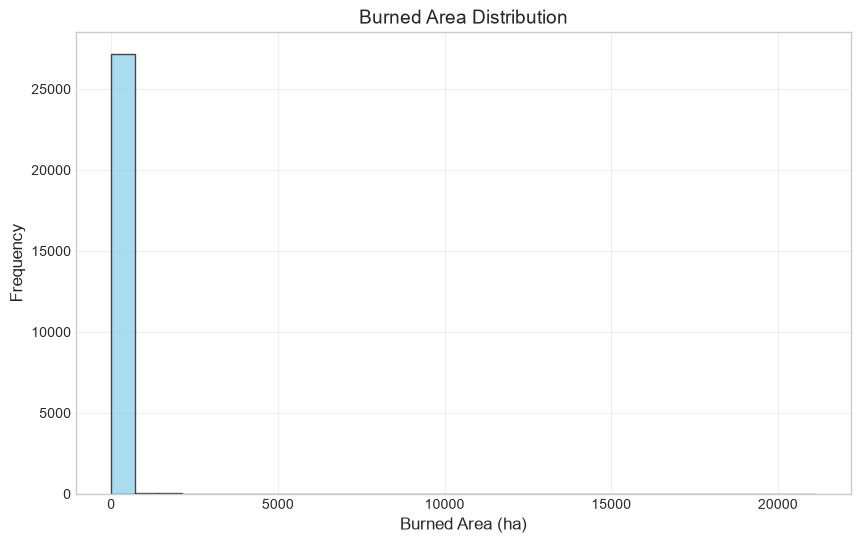

In [244]:
# Crear figura simple
superficie_data = df['superficie_quemada'].to_numpy()
plt.figure(figsize=(10, 6))

# Histograma
plt.hist(superficie_data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Burned Area Distribution', fontsize=14)
plt.xlabel('Burned Area (ha)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)

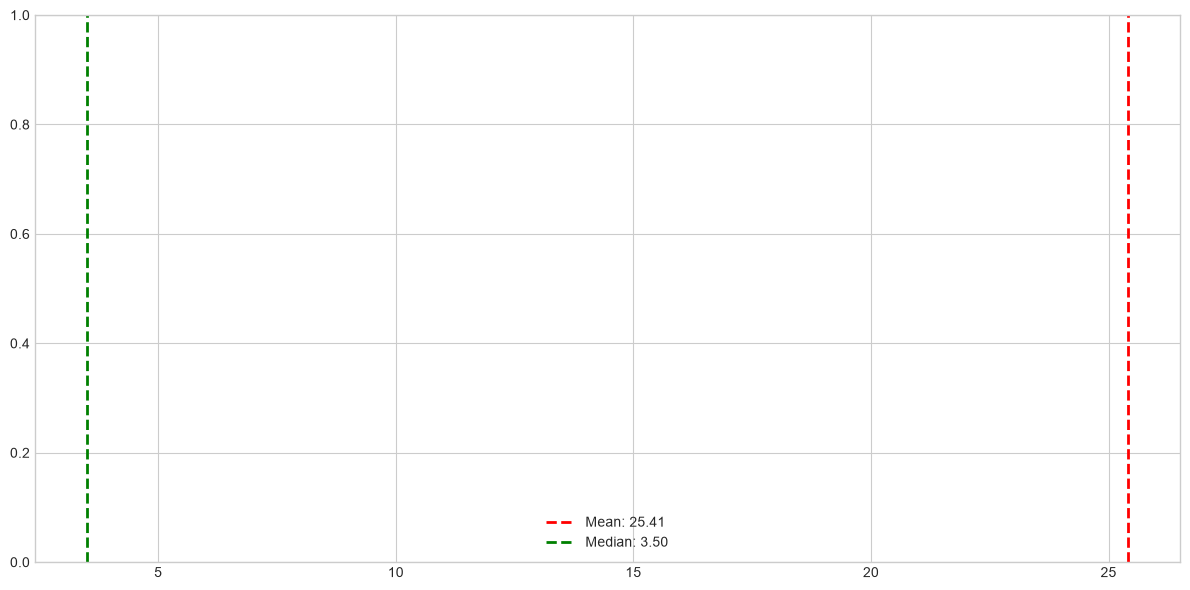

In [245]:
# Mostrar estadísticas en el gráfico
mean_val = np.mean(superficie_data)
median_val = np.median(superficie_data)
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
plt.legend()

plt.tight_layout()
plt.show()

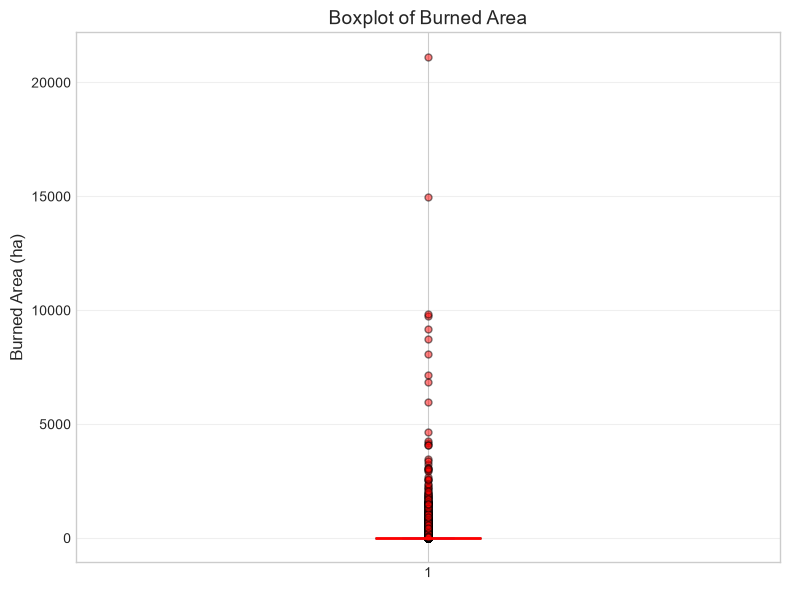

In [246]:
# --- CHART 2: BOXPLOT ---
plt.figure(figsize=(8, 6))

# Boxplot
plt.boxplot(superficie_data, orientation='vertical', patch_artist=True,
            boxprops=dict(facecolor='lightblue'),
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(color='blue'),
            capprops=dict(color='blue'),
            flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.5))

plt.title('Boxplot of Burned Area', fontsize=14)
plt.ylabel('Burned Area (ha)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

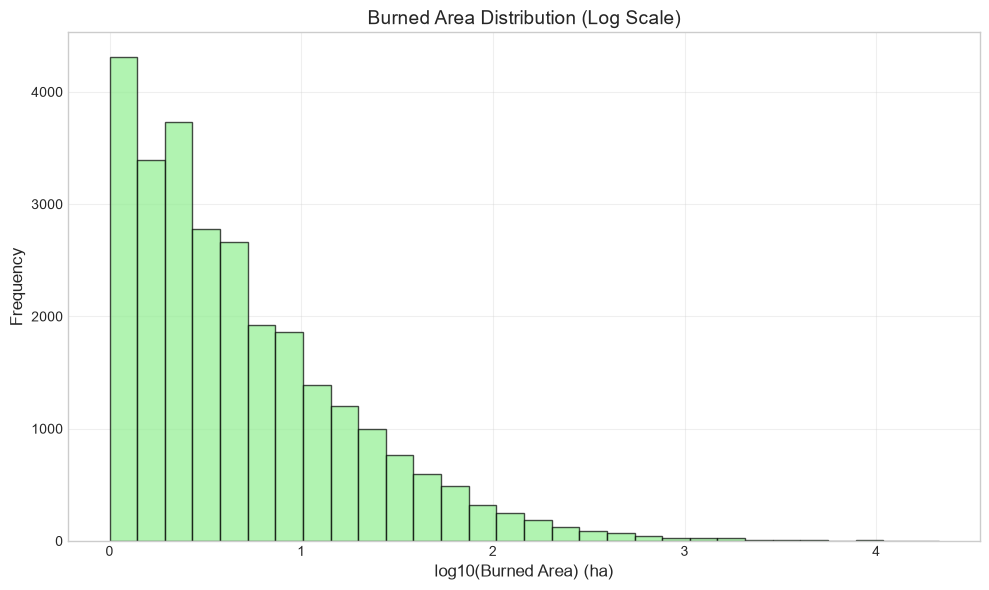

In [247]:
# --- CHART 3: HISTOGRAM IN LOGARITHMIC SCALE ---
plt.figure(figsize=(10, 6))

# Filtrar valores > 0 para el log
datos_log = superficie_data[superficie_data > 0]

if len(datos_log) > 0:
    plt.hist(np.log10(datos_log), bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
    plt.title('Burned Area Distribution (Log Scale)', fontsize=14)
    plt.xlabel('log10(Burned Area) (ha)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'No positive data', ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.show()

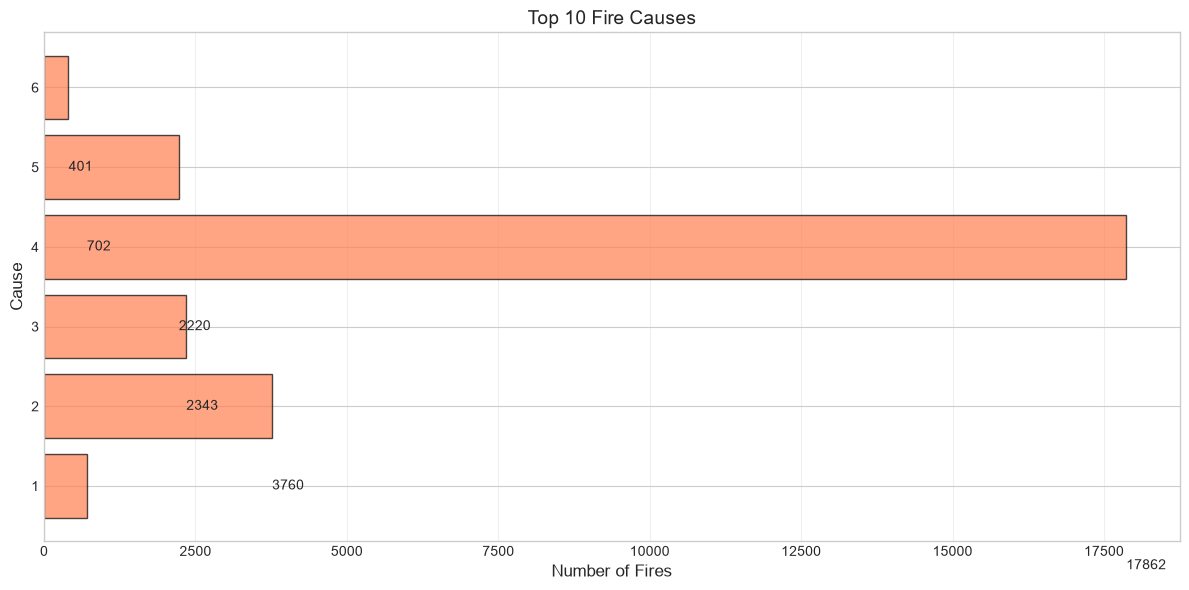

In [248]:
# --- CHART 4: BAR CHART BY CAUSES ---
# Obtener top 10 causas
causas_count = df.group_by('causa_incendio').agg([
    pl.len().alias('frecuencia')
]).sort('frecuencia', descending=True).head(10)

# Crear gráfico
plt.figure(figsize=(12, 6))

causas = causas_count['causa_incendio'].to_list()
frecuencias = causas_count['frecuencia'].to_numpy()

plt.barh(causas, frecuencias, color='coral', alpha=0.7, edgecolor='black')
plt.title('Top 10 Fire Causes', fontsize=14)
plt.xlabel('Number of Fires', fontsize=12)
plt.ylabel('Cause', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')

# Añadir valores
for i, (causa, freq) in enumerate(zip(causas, frecuencias)):
    plt.text(freq + 5, i, f'{freq}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

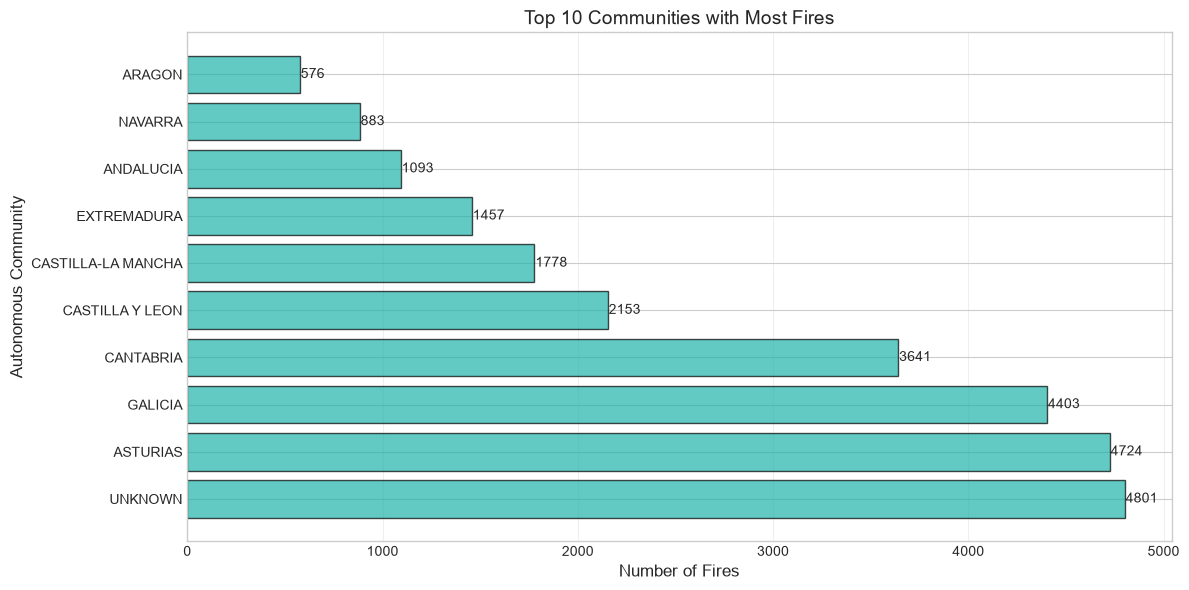

In [249]:
# --- CHART 5: COMMUNITIES WITH MOST FIRES ---
# Obtener top 10 comunidades
comunidades_count = df.group_by('cc_aa').agg([
    pl.len().alias('frecuencia')
]).sort('frecuencia', descending=True).head(10)

# Crear gráfico
plt.figure(figsize=(12, 6))

comunidades = comunidades_count['cc_aa'].to_list()
frecuencias = comunidades_count['frecuencia'].to_numpy()

plt.barh(comunidades, frecuencias, color='lightseagreen', alpha=0.7, edgecolor='black')
plt.title('Top 10 Communities with Most Fires', fontsize=14)
plt.xlabel('Number of Fires', fontsize=12)
plt.ylabel('Autonomous Community', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')

# Añadir valores
for i, (com, freq) in enumerate(zip(comunidades, frecuencias)):
    plt.text(freq + 5, i, f'{freq}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

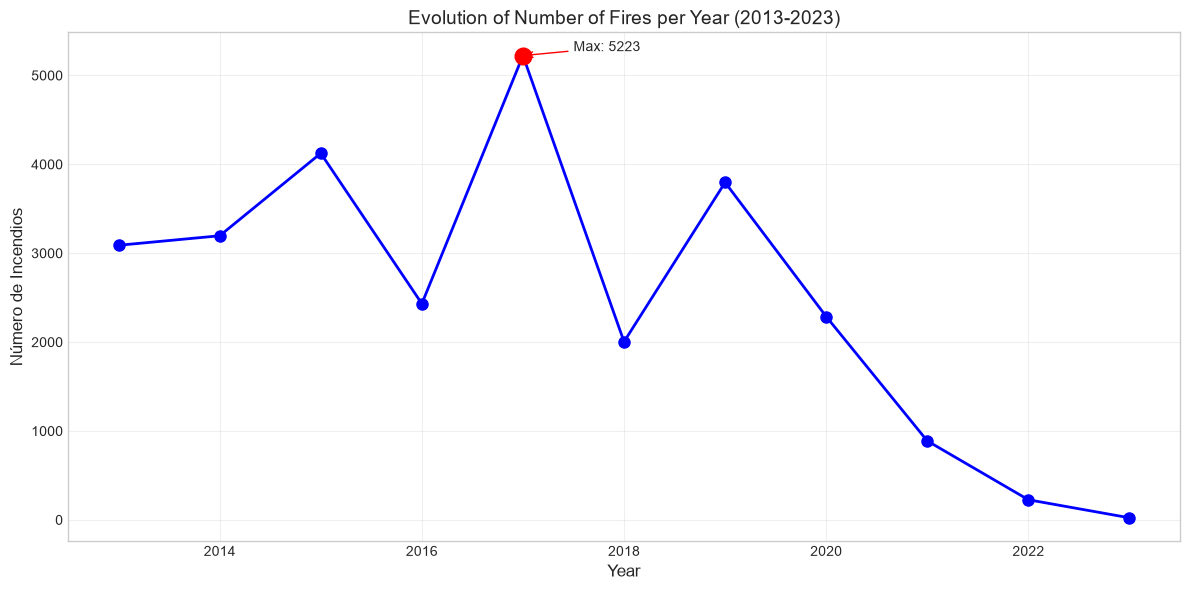

In [250]:
# --- CHART 6: TEMPORAL EVOLUTION (YEARS) ---
# Agrupar por año
incendios_por_año = df.group_by('año').agg([
    pl.len().alias('num_incendios')
]).sort('año')

# Crear gráfico
plt.figure(figsize=(12, 6))

años = incendios_por_año['año'].to_numpy()
num_incendios = incendios_por_año['num_incendios'].to_numpy()

plt.plot(años, num_incendios, 'o-', color='blue', linewidth=2, markersize=8)
plt.title('Evolution of Number of Fires per Year (2013-2023)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Número de Incendios', fontsize=12)
plt.grid(True, alpha=0.3)

# Marcar el año con más incendios
max_idx = np.argmax(num_incendios)
plt.plot(años[max_idx], num_incendios[max_idx], 'ro', markersize=12)
plt.annotate(f'Max: {num_incendios[max_idx]}', 
             xy=(años[max_idx], num_incendios[max_idx]),
             xytext=(años[max_idx]+0.5, num_incendios[max_idx]+50),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10)

plt.tight_layout()
plt.show()

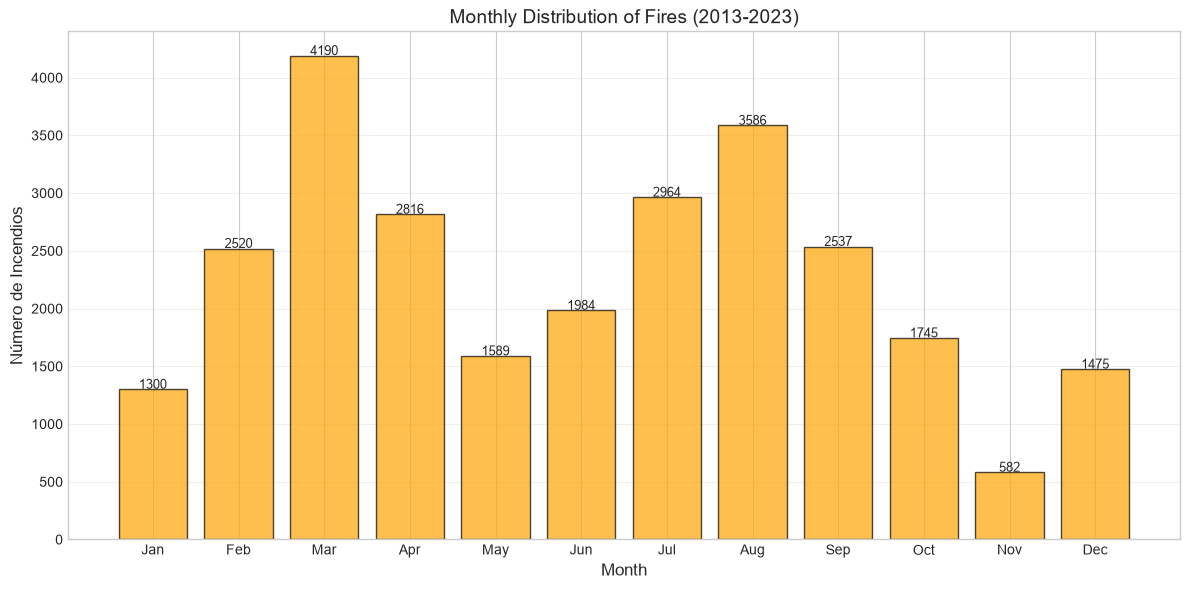

In [251]:
# --- CHART 7: MONTHLY DISTRIBUTION ---
# Agrupar por mes
incendios_por_mes = df.group_by('mes').agg([
    pl.len().alias('num_incendios')
]).sort('mes')

# Crear gráfico
plt.figure(figsize=(12, 6))

meses = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
num_incendios = incendios_por_mes['num_incendios'].to_numpy()

plt.bar(meses, num_incendios, color='orange', alpha=0.7, edgecolor='black')
plt.title('Monthly Distribution of Fires (2013-2023)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Número de Incendios', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

# Añadir valores
for i, (mes, freq) in enumerate(zip(meses, num_incendios)):
    plt.text(i, freq + 5, f'{freq}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [252]:
# Assignment of names to months in English
month_map = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}

df = df.with_columns(
    pl.col('mes').replace_strict(month_map).alias('month_name')
)

df[['mes', 'month_name']]

mes,month_name
i8,str
1,"""January"""
1,"""January"""
1,"""January"""
1,"""January"""
1,"""January"""
…,…
10,"""October"""
10,"""October"""
11,"""November"""


In [253]:
# Save preprocessed dataset to CSV
output_path = "../data/preprocessing/fires-all-prepro.csv"
df.write_csv(output_path)
print(f"Preprocessed dataset saved to: {output_path}")
print(f"Shape: {df.shape}")

Preprocessed dataset saved to: ../data/preprocessing/fires-all-prepro.csv
Shape: (27288, 12)


In [254]:
from pathlib import Path
Path("../data/processed").mkdir(parents=True, exist_ok=True)
df.write_parquet("../data/processed/fires_clean.parquet")

In [255]:
df.tail(30)

id,superficie_quemada,fecha_incendio,latitud,longitud,cc_aa,provincia,causa_incendio,año,mes,trimestre,month_name
i64,f64,date,str,str,str,str,i64,i32,i8,i8,str
2022340142,2.45,2022-09-24,"""42.28712037014961""","""-4.951681751070663""","""CASTILLA Y LEON""","""PALENCIA""",4,2022,9,3,"""September"""
2022210104,1.5,2022-09-26,"""37.6146057367309""","""-7.329232520699999""","""ANDALUCIA""","""HUELVA""",2,2022,9,3,"""September"""
2022340152,2.08,2022-10-13,"""42.033846732799596""","""-4.612518392234324""","""CASTILLA Y LEON""","""PALENCIA""",4,2022,10,4,"""October"""
2022210113,1.5,2022-10-14,"""37.26360722558594""","""-6.761950704212197""","""ANDALUCIA""","""HUELVA""",2,2022,10,4,"""October"""
2022210115,1.9,2022-10-14,"""37.24527393370685""","""-6.611114925064379""","""ANDALUCIA""","""HUELVA""",5,2022,10,4,"""October"""
…,…,…,…,…,…,…,…,…,…,…,…
2023300134,2.15,2023-10-16,"""38.325657513035644""","""-1.2788152400355388""","""MURCIA""","""MURCIA""",2,2023,10,4,"""October"""
2023300129,4.7,2023-10-19,"""37.62995950857133""","""-0.8418444276930938""","""MURCIA""","""MURCIA""",3,2023,10,4,"""October"""
2023300128,1.18,2023-11-27,"""38.48545412569731""","""-1.343063278399974""","""MURCIA""","""MURCIA""",2,2023,11,4,"""November"""
